In [1]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2

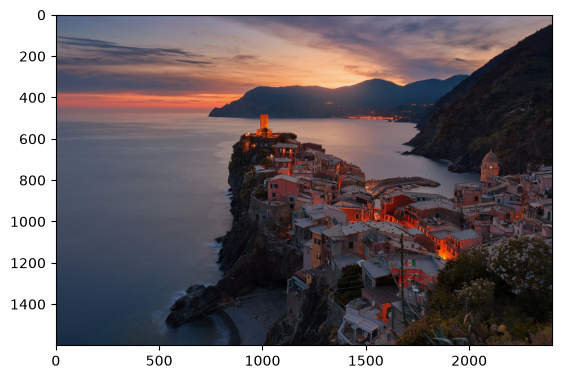

In [2]:
# reading the image
img = cv2.imread('/Users/vanshilpatel/Desktop/cv pdeu/exp2/Image.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [3]:
print(img.shape)

(1600, 2400, 3)


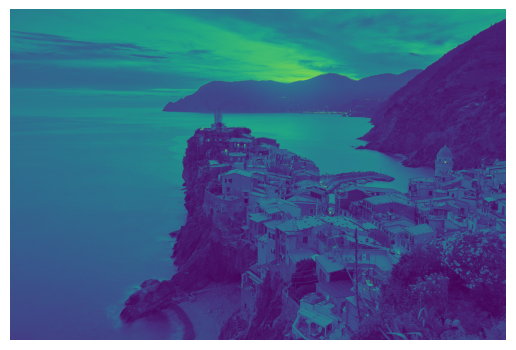

In [ ]:
img2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img2 ,)
plt.axis('off')
plt.show()

In [5]:
def salt_and_pepper_noise(image, prob=0.3):
    noisy = np.copy(image)
    rnd = np.random.rand(*image.shape)
    noisy[rnd < prob / 2] = 0
    noisy[rnd > 1 - prob / 2] = 255
    return noisy


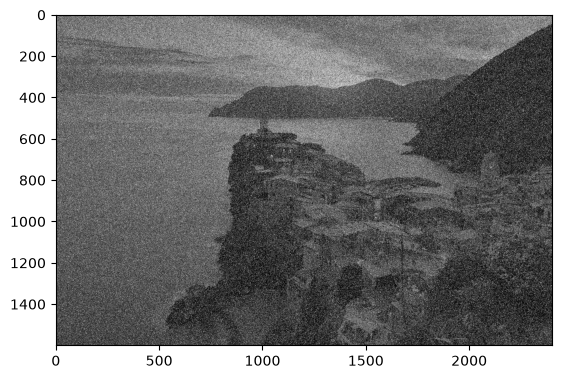

In [6]:
prob = 0.3
noisy_image = salt_and_pepper_noise(img2, prob)
plt.imshow(noisy_image, cmap='gray')
plt.show()

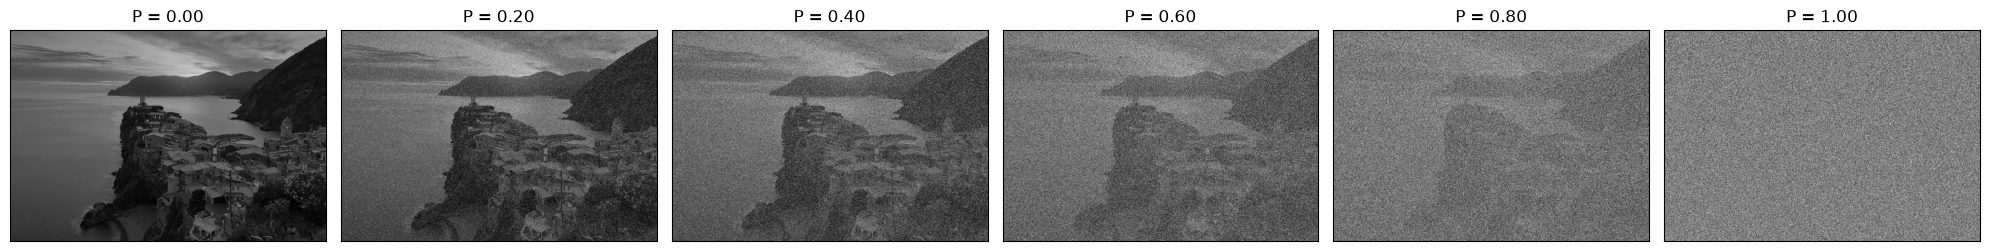

In [7]:
# noise
probabilities = np.arange(0, 1.1, 0.20)

fig, axes = plt.subplots(nrows=1, ncols=len(probabilities), figsize=(20, 4))

for i, p in enumerate(probabilities):
    result = salt_and_pepper_noise(img2, p)

    axes[i].imshow(result, cmap="gray")
    axes[i].set_title(f"P = {p:.2f}")
    axes[i].set_xticks([])
    axes[i].set_yticks([])

fig.tight_layout()
plt.show()

In [8]:
# applying median filter
def median_filter(img2, window_size=3):
    pad = window_size // 2
    padded = cv2.copyMakeBorder(img2, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    result = np.zeros_like(img2, dtype=np.uint8)

    h, w = img2.shape[:2]
    for i in range(h):
        for j in range(w):
            window = padded[i:i+window_size, j:j+window_size]
            result[i, j] = np.median(window)

    return result

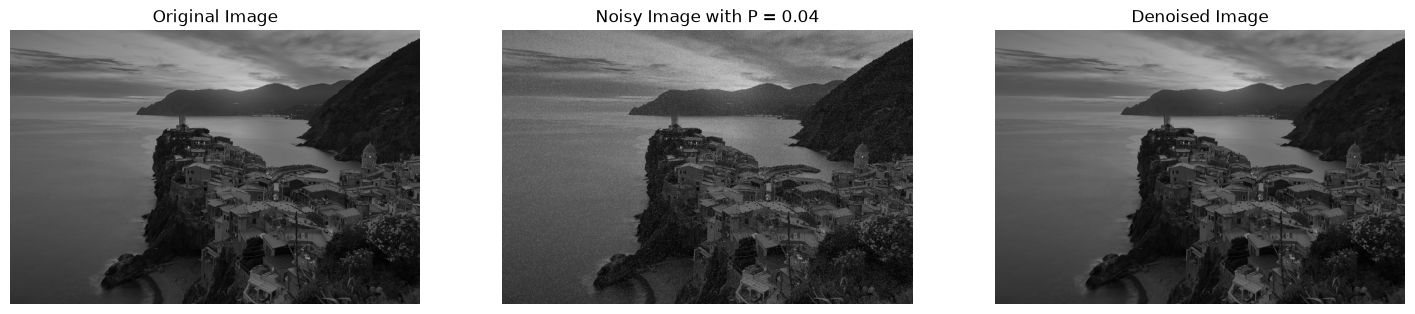

In [9]:
#making noisy image
prob = 0.04
noisy_img= salt_and_pepper_noise(img2, prob)

# denoising the image using median filter
denoised_img = median_filter(noisy_img, 3)
plt.figure(figsize=(18, 6))

# plotting the original, noisy, and denoised images
plt.subplot(1, 3, 1)
plt.imshow(img2, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy_img, cmap='gray')
plt.title('Noisy Image with P = 0.04')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(denoised_img, cmap='gray')
plt.title('Denoised Image')
plt.axis('off')

plt.show()